# Reddit data 

## Overview
This notebook collects Reddit posts related to semiconductor companies (NVDA, AMD, INTC) 
using the Arctic Shift API. The collected data will be used as a source of informal 
market sentiment, which will later be combined with financial news headlines, stock price 
data with technical indicators, and macroeconomic market data to predict stock price 
movements and volatility.

[Arctic Shift](https://arctic-shift.photon-reddit.com) is used instead of the official 
Reddit API (PRAW) because Reddit's 2023 API rate limiting restrictions and PRAW's inability to retrieve deleted or archived posts.

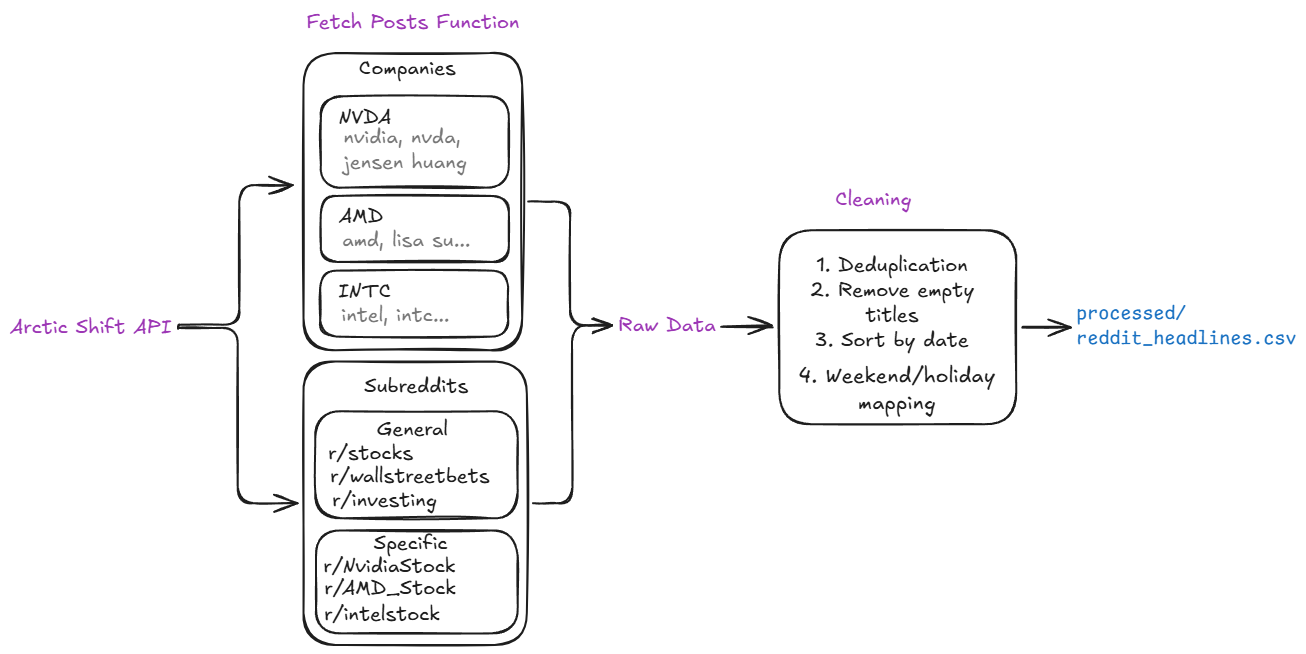

## 1. Configuration

The following section defines the companies, keywords, subreddits, and time period 
used for data collection.

The selected companies are all major players in the semiconductor industry, allowing 
for cross-company sentiment comparison:
- **NVDA (Nvidia)** — dominant GPU and AI chip manufacturer
- **AMD (Advanced Micro Devices)** — main competitor to both Nvidia and Intel
- **INTC (Intel)** —  major CPU manufacturer, currently undergoing restructuring


In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime,timedelta

COMPANIES = {
    "NVDA": ["nvidia", "nvda", "jensen huang"],
    "AMD":  ["amd", "advanced micro devices", "lisa su"],
    "INTC": ["intel", "intc", "pat gelsinger", "lip-bu tan"] 

}

SUBREDDITS_GENERAL = ["stocks", "wallstreetbets", "investing"]
SUBREDDITS_SPECIFIC = {
    "NVDA": ["NvidiaStock"],
    "AMD": ["AMD_Stock"],
    "INTC": ["intelstock"]
}

START_DATE = "2016-04-28"
END_DATE = "2026-03-31"

start_ts = int(datetime.strptime(START_DATE, "%Y-%m-%d").timestamp())
end_ts = int(datetime.strptime(END_DATE, "%Y-%m-%d").timestamp())

print(f"Period: {START_DATE} to {END_DATE}")

Period: 2016-04-28 to 2026-03-31


## 2. Data collection function

The `fetch_posts` function retrieves Reddit posts from the Arctic Shift API for a given 
subreddit and a list of keywords. It handles three key challenges automatically:

- **Pagination** — the API returns at most 100 posts per call, so the function 
advances the time cursor after each batch until the full date range is covered
- **Deduplication** — since the same post can be matched by multiple keywords 
within the same company (for example "nvidia" and "jensen huang" can be in the same title), already seen post IDs are tracked and skipped to avoid counting the same post twice for a single company
- **Retries** — in case of HTTP errors or timeouts, the function retries up to 
3 times before skipping the current keyword

Each collected post is stored with the following fields: `post_id`, `date`, 
`subreddit`, `title`, `score`, and `num_comments`.

In [5]:
BASE_URL    = "https://arctic-shift.photon-reddit.com/api/posts/search"
MAX_RETRIES = 3

def fetch_posts(
    subreddit: str,
    keywords: list[str],
    start_ts: int,
    end_ts: int,
    limit: int = 100,
) -> list[dict]:
    """
    Fetch Reddit posts from the Arctic Shift API for one subreddit
    and a list of keywords. Handles pagination, deduplication, and
    retries automatically.

    Args:
        subreddit : Target subreddit name (without r/).
        keywords  : List of search terms (case-insensitive on the API side).
        start_ts  : Unix timestamp -- start of the date range.
        end_ts    : Unix timestamp -- end of the date range.
        limit     : Number of posts to request per API call (max 100).

    Returns:
        List of post dicts with keys: post_id, date, subreddit,
        title, score, num_comments.
    """
    seen_ids: set[str] = set()
    all_posts: list[dict] = []

    for keyword in keywords:
        after = start_ts
        consecutive_errors = 0

        while after < end_ts:
            params = {
                "subreddit": subreddit,
                "title":     keyword,
                "after":     int(after),
                "before":    int(end_ts),
                "limit":     limit,
                "sort":      "asc",
            }

            try:
                response = requests.get(BASE_URL, params=params, timeout=15)

                # Non-200 response
                if response.status_code != 200:
                    consecutive_errors += 1
                    print(
                        f"  HTTP {response.status_code} -- "
                        f"r/{subreddit} | '{keyword}' "
                        f"(attempt {consecutive_errors}/{MAX_RETRIES})"
                    )
                    if consecutive_errors >= MAX_RETRIES:
                        print(f"  Skipping '{keyword}' after {MAX_RETRIES} failures.")
                        break
                    time.sleep(5)
                    continue

                consecutive_errors = 0
                posts = response.json().get("data", [])

                # No more posts for this keyword
                if not posts:
                    break

                # Deduplicate and collect
                new_count = 0
                for post in posts:
                    post_id = post.get("id")
                    if not post_id or post_id in seen_ids:
                        continue
                    seen_ids.add(post_id)
                    new_count += 1
                    all_posts.append({
                        "post_id":      post_id,
                        "date":         datetime.utcfromtimestamp(
                                            post.get("created_utc", 0)
                                        ).strftime("%Y-%m-%d"),
                        "subreddit":    subreddit,
                        "title":        post.get("title", ""),
                        "score":        post.get("score", 0),
                        "num_comments": post.get("num_comments", 0),
                    })

                # Advance pagination cursor
                last_ts = posts[-1].get("created_utc")
                if not last_ts:
                    break
                after = last_ts + 1

                print(
                    f"  r/{subreddit} | '{keyword}' | "
                    f"{new_count} new posts | "
                    f"up to {datetime.utcfromtimestamp(after).strftime('%Y-%m-%d')}"
                )
                time.sleep(1)

            except requests.exceptions.Timeout:
                consecutive_errors += 1
                print(
                    f"  Timeout -- r/{subreddit} | '{keyword}' "
                    f"(attempt {consecutive_errors}/{MAX_RETRIES})"
                )
                if consecutive_errors >= MAX_RETRIES:
                    print(f"  Skipping '{keyword}' after {MAX_RETRIES} timeouts.")
                    break
                time.sleep(10)

            except Exception as exc:
                consecutive_errors += 1
                print(f"  Unexpected error: {exc}")
                if consecutive_errors >= MAX_RETRIES:
                    break
                time.sleep(5)

    return all_posts

## 3. Collecting posts

This section runs the data collection across all configured companies and subreddits.
For each company, posts are fetched from both general and company-specific subreddits,
with two additional fields added to each post:

- **`company`** — ticker symbol of the company the post is associated with (e.g. NVDA, AMD, INTC)
- **`source_type`** — indicates whether the post came from a general financial subreddit 
(`general`) or a company-specific subreddit (`specific`)

In [6]:
all_data = []

for company, keywords in COMPANIES.items():
    print(f"\n{'='*50}")
    print(f"Collecting data for: {company}")
    print(f"{'='*50}")
    
    # General investing subreddits
    for subreddit in SUBREDDITS_GENERAL:
        print(f"\nr/{subreddit}:")
        posts = fetch_posts(subreddit, keywords, start_ts, end_ts)
        for post in posts:
            post["company"] = company
            post["source_type"] = "general"
        all_data.extend(posts)
        print(f"Total: {len(posts)} posts")
    
    # Company-specific subreddits
    for subreddit in SUBREDDITS_SPECIFIC[company]:
        print(f"\nr/{subreddit}:")
        posts = fetch_posts(subreddit, keywords, start_ts, end_ts)
        for post in posts:
            post["company"] = company
            post["source_type"] = "specific"
        all_data.extend(posts)
        print(f"Total: {len(posts)} posts")

print("\n" + "=" * 50)
print(f"Total collected posts: {len(all_data)}")
print("=" * 50)



r/stocks:


C:\Users\WIN10\AppData\Local\Temp\ipykernel_25084\3039203156.py:78: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  "date":         datetime.utcfromtimestamp(
C:\Users\WIN10\AppData\Local\Temp\ipykernel_25084\3039203156.py:96: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  f"up to {datetime.utcfromtimestamp(after).strftime('%Y-%m-%d')}"


  r/stocks | 'nvidia' | 100 new posts | up to 2018-11-15
  r/stocks | 'nvidia' | 100 new posts | up to 2020-08-21
  r/stocks | 'nvidia' | 100 new posts | up to 2021-03-24
  r/stocks | 'nvidia' | 100 new posts | up to 2022-01-17
  r/stocks | 'nvidia' | 100 new posts | up to 2022-09-29
  r/stocks | 'nvidia' | 100 new posts | up to 2023-07-18
  r/stocks | 'nvidia' | 100 new posts | up to 2024-01-07
  r/stocks | 'nvidia' | 100 new posts | up to 2024-02-27
  r/stocks | 'nvidia' | 100 new posts | up to 2024-05-08
  r/stocks | 'nvidia' | 100 new posts | up to 2024-06-09
  r/stocks | 'nvidia' | 100 new posts | up to 2024-07-17
  r/stocks | 'nvidia' | 100 new posts | up to 2024-09-24
  r/stocks | 'nvidia' | 100 new posts | up to 2024-12-19
  r/stocks | 'nvidia' | 100 new posts | up to 2025-01-30
  r/stocks | 'nvidia' | 100 new posts | up to 2025-04-04
  r/stocks | 'nvidia' | 100 new posts | up to 2025-06-03
  r/stocks | 'nvidia' | 100 new posts | up to 2025-08-04
  r/stocks | 'nvidia' | 100 new

## 4. Data cleaning

Before saving, the collected data is cleaned in several steps:

- **Deduplication** — posts with duplicate `post_id` are removed
- **Empty titles** — posts with missing, blank titles or titles with only one word are dropped since the title 
is the primary text used for sentiment analysis
- **Sorting** — posts are sorted chronologically by date to prepare the data 
for time-series analysis in later stages

In [7]:
df = pd.DataFrame(all_data)

# Remove duplicates
df = df.drop_duplicates(subset=["post_id"])

# Remove rows without title
df = df[df["title"].str.strip() != ""]

# Remove rows where title contains only one word (for example, only name of company)
df = df[df['title'].str.split().str.len() > 1]

# Sort by date
df = df.sort_values("date")

# Reset index
df = df.reset_index(drop=True)

print(f"After cleaning: {len(df)} posts")
print(f"\nDistribution by company:")
print(df["company"].value_counts())
print(f"\nDistribution by subreddits:")
print(df["subreddit"].value_counts())
print(f"\nExample:")
df.head()

After cleaning: 59673 posts

Distribution by company:
company
AMD     27794
NVDA    24784
INTC     7095
Name: count, dtype: int64

Distribution by subreddits:
subreddit
wallstreetbets    30470
AMD_Stock         14615
stocks             6510
NvidiaStock        3786
investing          2290
intelstock         2002
Name: count, dtype: int64

Example:


,post_id,date,subreddit,title,score,num_comments,company,source_type
0,4gwa40,2016-04-28,investing,Should I buy GILD or AMD?,0,4,AMD,general
1,4gtvvv,2016-04-28,wallstreetbets,Here's my viewpoint on AMD. No numbers. Just t...,49,126,AMD,general
2,4gv42r,2016-04-28,wallstreetbets,Ain't never shorted nothin'. Do ya'll reckon A...,0,4,AMD,general
3,4gw716,2016-04-28,stocks,Should I buy GILD or AMD?,1,1,AMD,general
4,4gz6we,2016-04-29,wallstreetbets,[shitpost] AMD embodies the indecisiveness in ...,4,0,AMD,general


After cleaning, the dataset contains **59,675 posts** distributed across three companies 
and six subreddits.


In [8]:
df = df.drop(columns=["score"])

**Score removal** — the post score is excluded since Arctic Shift captures the 
score at the time of collection rather than at the time of posting, meaning it 
reflects future community engagement and would introduce data leakage into the model

## 5. News coverage analysis
Since stock markets do not operate on weekends or public holidays, Reddit posts 
published on non-trading days are mapped to the most recent previous trading day. 
For example, a post published on Saturday or Sunday is assigned to Friday's trading 
date, as it reflects sentiment that will influence the following Monday's market opening.


In [9]:
technical_df = pd.read_csv('datasets/processed/yahoo_finance.csv')
technical_df['date'] = pd.to_datetime(technical_df['date'])

# Set of unique trading days
trading_days_set = set(technical_df['date'].dt.date.unique())
trading_days = len(trading_days_set)

In [11]:
def map_to_previous_trading_day(date):
    d = date.date()
    min_date = min(trading_days_set)
    
    if d < min_date:
        return pd.NaT
    
    count = 0
    while d not in trading_days_set:
        d -= timedelta(days=1)
        count += 1
        if count > 10 or d < min_date:
            return pd.NaT
    
    return pd.Timestamp(d)
df['date'] = pd.to_datetime(df['date'])
df['trading_date'] = df['date'].apply(map_to_previous_trading_day)

In [12]:
print(f'\nTotal trading days: {trading_days}')
print('\nDays with at least one post per company:')
for company in ['NVDA', 'AMD', 'INTC']:
    days_covered = df[df['company'] == company]['trading_date'].nunique()
    pct = days_covered / trading_days * 100
    print(f'  {company}: {days_covered} days covered ({pct:.1f}% of trading days)')


Total trading days: 2493

Days with at least one post per company:
  NVDA: 2104 days covered (84.4% of trading days)
  AMD: 2468 days covered (99.0% of trading days)
  INTC: 1395 days covered (56.0% of trading days)


Days without Reddit posts will be assigned a sentiment value of 0 (neutral sentiment), following the 
same imputation approach applied to news data.

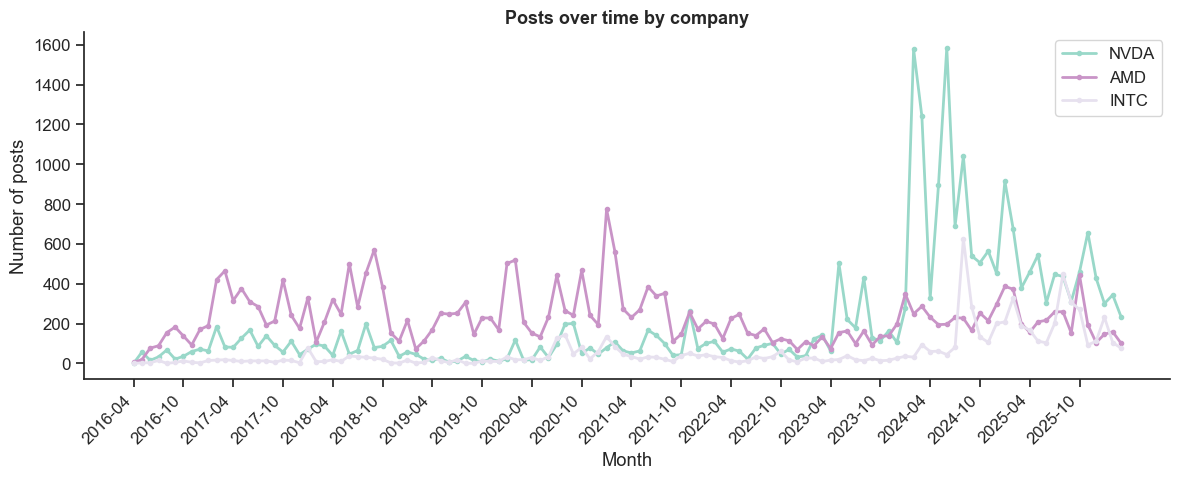

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

company_colors = {"NVDA": "#99d8c9", "AMD": "#c994c7", "INTC": "#e7e1ef"}

sns.set_theme(style="ticks", font_scale=1.1)

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")

fig, ax = plt.subplots(figsize=(12, 5))

for company, color in company_colors.items():
    monthly = df[df["company"] == company].groupby("month").size()
    ax.plot(monthly.index.astype(str), monthly.values,
            label=company, color=color, linewidth=2, marker="o", markersize=3)

ax.set_title("Posts over time by company", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of posts")
ax.set_xlabel("Month")
ax.legend()
sns.despine()

tick_labels = sorted(df["month"].unique().astype(str))[::6]
tick_positions = range(0, len(df["month"].unique()), 6)
ax.set_xticks(list(tick_positions))
ax.set_xticklabels(tick_labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()

The chart presents the monthly distribution of Reddit posts related to NVDA, AMD, and INTC from 2016 to 2026.

**NVIDIA** exhibits a substantial increase in discussion activity beginning in 2023, with several pronounced spikes throughout 2024 that likely correspond to the rapid expansion of the AI market, major earnings announcements, and the introduction of Blackwell AI chips at GTC 2024.

In contrast, **AMD** demonstrates a more stable and consistent discussion pattern over time, while **INTC** maintains comparatively lower activity levels with some spikes around 2024. 

The observed fluctuations in posting activity suggest that Reddit discussion volume itself may represent a useful predictive feature and will therefore be considered as an additional attribute in the later modeling phase (as `posts_count`).

## 6. Experiment tracking with MLflow and saving the dataset

The final step logs the scraping run to MLflow and saves the cleaned dataset to disk.
MLflow tracking is configured to use a local SQLite database (`mlflow.db`), which 
stores all experiment metadata without requiring a remote server.

The following information is logged for reproducibility:

- **Parameters** — collection configuration including date range, company list, 
and all subreddits used (both general and company-specific)
- **Metrics** — total number of posts, unique post count, number of unique subreddits, 
and post count per company

This ensures that the data collection step is fully reproducible — any future 
re-run with different parameters will be tracked as a separate experiment in MLflow.

In [14]:
import os
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db") 

mlflow.set_experiment("reddit_scraping")

with mlflow.start_run(run_name="arctic_shift_scraping"):

    # Log parameters
    mlflow.log_param("start_date", START_DATE)
    mlflow.log_param("end_date", END_DATE)
    mlflow.log_param("companies", ", ".join(COMPANIES.keys()))
    mlflow.log_param("general_subreddits", ", ".join(SUBREDDITS_GENERAL))

    for company, subreddits in SUBREDDITS_SPECIFIC.items():
        mlflow.log_param(
            f"specific_subreddits_{company}",
            ", ".join(subreddits)
        )

    # Log dataset metrics
    mlflow.log_metric("total_posts", len(df))
    mlflow.log_metric("unique_posts", df["post_id"].nunique())
    mlflow.log_metric("unique_subreddits", df["subreddit"].nunique())

    for company in COMPANIES.keys():
        company_count = len(df[df["company"] == company])
        mlflow.log_metric(f"posts_{company}", company_count)

    # Save dataset
    output_path = "datasets/processed/reddit_headlines.csv"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    df.to_csv(output_path, index=False)

    print(f"Data saved to: {output_path}")
    print("MLflow run completed.")

2026/05/29 11:50:13 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



Data saved to: datasets/processed/reddit_headlines.csv
MLflow run completed.
